Now that I have selected the templates I will find the thresholds.

In [1]:
from pathlib import Path
from calibration_calcs import save_threshold_new, dtw_cross_costs, compute_roc_curve, find_threshold_youden_from_roc, compute_auc, plot_roc_curve, plot_dtw_scatter
from feature import make_mfcc_extractor, load_features_from_json

DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"

DATA_26 = Path(r"C:\Users\HP\Desktop\Skripsie data\26")
RESULTS_26 = DATA_26 / "template_selections"

RESULTS = Path(r"C:\Users\HP\Desktop\Skripsie data\Results")
THRESHOLDS = RESULTS / "Thresholds"

file_name = "5_Templates"
n_temps = 5
n_calib = 10

[single_tone] Threshold: 8.9090 (J = 0.9800)


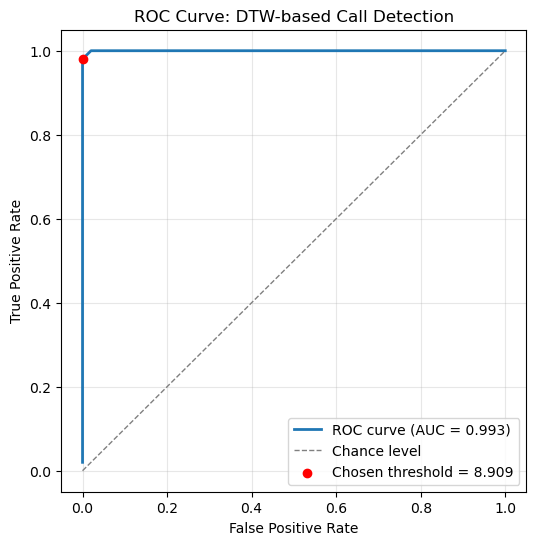

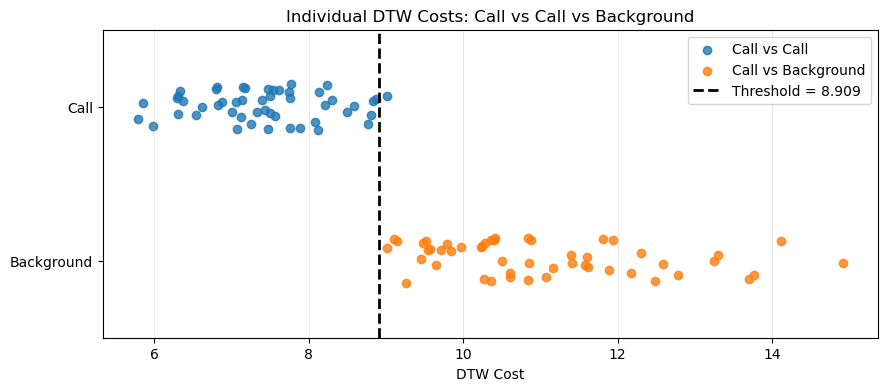

Saved threshold for 'single_tone' [mfcc] to 5_Templates_mfcc_single_tone_threshold.json: threshold=8.9090, J=0.9800, AUC=0.9928
[multi_tone] Threshold: 9.8176 (J = 0.7600)


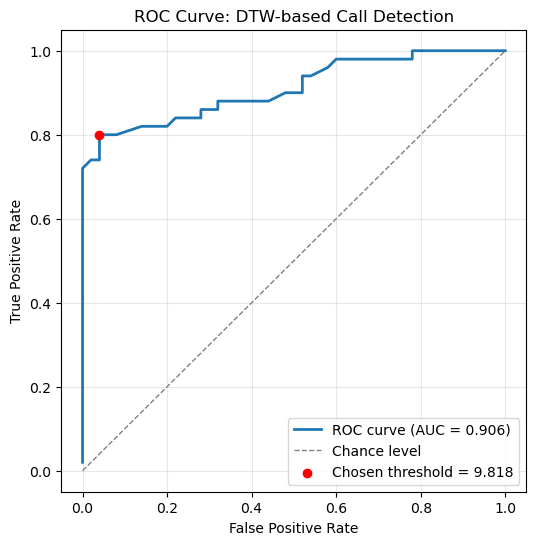

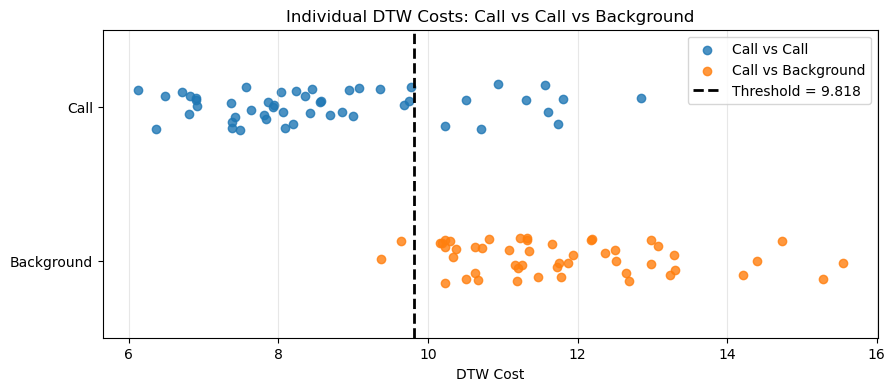

Saved threshold for 'multi_tone' [mfcc] to 5_Templates_mfcc_multi_tone_threshold.json: threshold=9.8176, J=0.7600, AUC=0.9056
[burst_tonal] Threshold: 11.5535 (J = 0.6600)


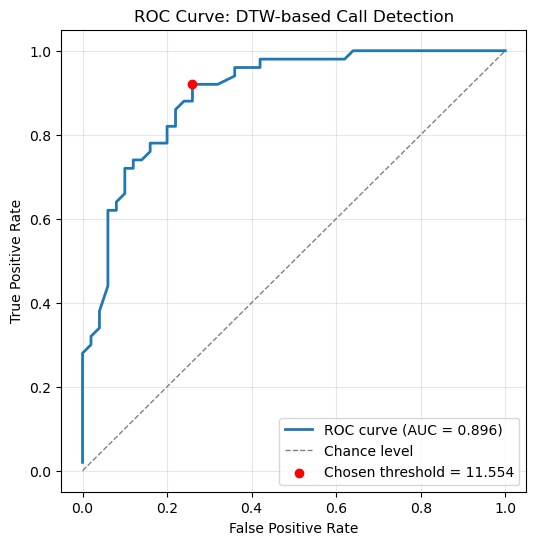

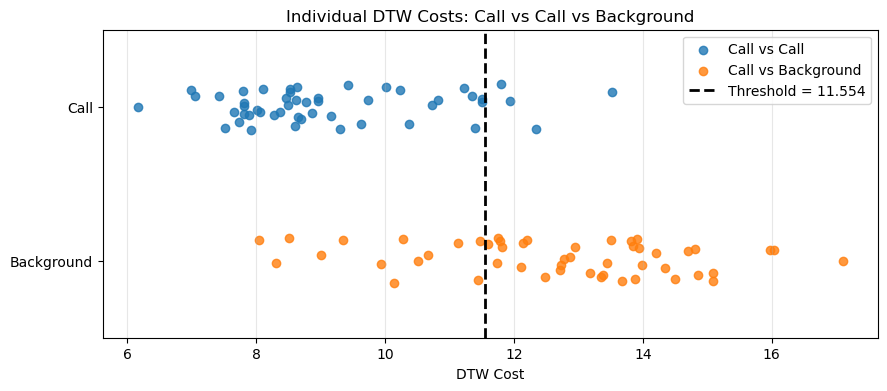

Saved threshold for 'burst_tonal' [mfcc] to 5_Templates_mfcc_burst_tonal_threshold.json: threshold=11.5535, J=0.6600, AUC=0.8962


In [2]:
extractor = make_mfcc_extractor()     

TEMPLATE_STEM = "20230429_Templates_20230429_102841"
CALIB_FILES = {
    "single_tone": "ST_CALIB_26_20230426_075505_single_tone_templates.json",
    "multi_tone":  "MT_CALIB_26_20230426_075505_multi_tone_templates.json",
    "burst_tonal": "BT_CALIB_26_20230426_075505_burst_tonal_templates.json",
}

bg_specs = load_features_from_json(
    RESULTS_26 / "Bground_CALIB_26_20230426_075505_background.json", extractor, n_calib)

for call_type, calib_file in CALIB_FILES.items():
    template_specs = load_features_from_json(
        RESULTS_29 / f"{TEMPLATE_STEM}_{call_type}_templates.json", extractor, n_temps)
    calib_specs = load_features_from_json(RESULTS_26 / calib_file, extractor, n_calib)

    call_costs, _ = dtw_cross_costs(template_specs, calib_specs, extractor.metric)
    bg_costs, _   = dtw_cross_costs(template_specs, bg_specs,    extractor.metric)

    fpr, tpr, thresholds = compute_roc_curve(call_costs, bg_costs)
    threshold, j_stat = find_threshold_youden_from_roc(fpr, tpr, thresholds)
    auc = compute_auc(fpr, tpr)
    print(f"[{call_type}] Threshold: {threshold:.4f} (J = {j_stat:.4f})")

    _ = plot_roc_curve(call_costs, bg_costs, best_threshold=threshold)
    plot_dtw_scatter(call_costs, bg_costs, threshold=threshold)

    save_threshold_new(threshold, j_stat, auc, call_type=call_type,
                   file_label=file_name, results_dir=THRESHOLDS,
                   n_templates=n_temps, n_background=n_calib,
                   feature_name=extractor.name, feature_params=extractor.params)